# Gratis Fiyat Analizi — Fırsat Skoru ve Sonuçlar

**Notebook:** 04 — Fırsat Skoru ve Sonuçların Yorumlanması  
**Proje:** Gratis'te Fiyat Davranışı Analizi: Tüketici için Veri Odaklı Alışveriş Rehberi

Bu notebook'ta önceki aşamalarda oluşturulan ürün özellikleri ve kümeleme sonuçları kullanılarak tüketiciye yönelik bir **fırsat skoru** oluşturulur.

## Amaç

Bu aşamanın amacı, bir ürünün güncel fiyatının geçmiş fiyat davranışına göre ne kadar avantajlı olduğunu değerlendirmektir.

Fırsat skoru şu soruya cevap verir:

> Bu ürün şu anda gerçekten iyi bir fırsat mı, yoksa beklemek daha mı mantıklı?

## Kullanılan Bilgiler

Fırsat skoru hesaplanırken şu değişkenler dikkate alınır:

1. Ürünün güncel fiyatının geçmiş minimum ve maksimum fiyatına göre konumu
2. Güncel indirim oranı
3. Ürünün kampanya etiketi taşıyıp taşımadığı
4. Ürünün ait olduğu indirim davranışı kümesi
5. Ürünün fiyat oynaklığı ve geçmiş indirim karakteri

## Çıktılar

Bu notebook sonunda aşağıdaki dosya oluşturulacaktır:

`../data/processed/urun_firsat_skorlari.csv`

In [15]:
# === KÜTÜPHANELER ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# === GÖRSEL AYARLARI ===

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Renkler
GRATIS_PEMBE = "#E91E63"
GRATIS_LACIVERT = "#1A237E"
GRATIS_GRI = "#90A4AE"
ACCENT = "#FF9800"

# === VERİ YOLLARI ===

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

CLEAN_PATH = PROCESSED_DIR / "gratis_clean.csv"
CLUSTER_PATH = PROCESSED_DIR / "urun_kumeleri.csv"

# === VERİYİ OKU ===

df = pd.read_csv(
    CLEAN_PATH,
    parse_dates=["tarih", "kayit_zamani", "snapshot_gun"],
    encoding="utf-8-sig"
)

urun_kumeleri = pd.read_csv(
    CLUSTER_PATH,
    encoding="utf-8-sig"
)

print("Veriler yüklendi ✓")
print(f"Temiz gözlem verisi: {len(df):,} satır")
print(f"Ürün küme verisi: {len(urun_kumeleri):,} ürün")

print("\nTemiz veri tarih aralığı:")
print(f"{df['snapshot_gun'].min().date()} → {df['snapshot_gun'].max().date()}")

display(urun_kumeleri.head(3))

Veriler yüklendi ✓
Temiz gözlem verisi: 118,812 satır
Ürün küme verisi: 10,628 ürün

Temiz veri tarih aralığı:
2026-04-04 → 2026-05-06


,urun_id,isim,marka,kategori,gozlem_sayisi,ortalama_fiyat,medyan_fiyat,min_fiyat,max_fiyat,fiyat_std,...,begeni_sayi,ilk_fiyat,son_fiyat,fiyat_araligi,fiyat_araligi_orani,fiyat_degisim_orani,populerlik_skoru,log_ortalama_fiyat,cluster,cluster_adi
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,15,335.133333,359.0,180.0,359.0,62.983974,...,6000.0,180.0,359.0,179.0,0.498607,0.994444,11.097577,5.817508,0,Sürekli İndirimli Ana Katalog Ürünleri
1,10000236,Kalyon Tırnak Besleyici,Kalyon,Makyaj,10,249.550000,265.5,106.0,265.5,50.438329,...,34000.0,106.0,265.5,159.5,0.600753,1.504717,14.816172,5.523659,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri
2,10000237,Kalyon Oje Kurutucu Sprey,Kalyon,Makyaj,10,300.950000,346.0,103.5,346.0,95.321226,...,9000.0,138.0,346.0,242.5,0.700867,1.507246,12.472387,5.710261,2,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri


---

## 1) Güncel Ürün Durumunun Çıkarılması

Fırsat skoru, ürünün en güncel fiyat durumuna göre hesaplanacaktır. Bu nedenle her ürün için veri setindeki en son gözlem alınmıştır.

Bu aşamada her ürün için:

- Güncel fiyat
- Güncel eski fiyat
- Güncel indirim oranı
- Güncel kampanya etiketi
- Son gözlem tarihi

bilgileri çıkarılmıştır.

In [16]:
# === HER ÜRÜNÜN EN GÜNCEL GÖZLEMİNİ AL ===

df_latest = (
    df.sort_values(["urun_id", "snapshot_gun", "kayit_zamani"])
      .groupby("urun_id")
      .tail(1)
      .copy()
)

df_latest = df_latest[
    [
        "urun_id",
        "fiyat",
        "eski_fiyat",
        "indirim_yuzde",
        "indirimde_mi",
        "kampanya",
        "snapshot_gun",
        "url"
    ]
].rename(columns={
    "fiyat": "guncel_fiyat",
    "eski_fiyat": "guncel_eski_fiyat",
    "indirim_yuzde": "guncel_indirim",
    "indirimde_mi": "guncel_indirimde_mi",
    "kampanya": "guncel_kampanya",
    "snapshot_gun": "guncel_tarih"
})

print("Güncel ürün durumu çıkarıldı ✓")
print(f"Güncel ürün sayısı: {len(df_latest):,}")

display(df_latest.head())

Güncel ürün durumu çıkarıldı ✓
Güncel ürün sayısı: 10,628


,urun_id,guncel_fiyat,guncel_eski_fiyat,guncel_indirim,guncel_indirimde_mi,guncel_kampanya,guncel_tarih,url
14,10000049,359.0,451.0,20.4,True,Kampanya Yok,2026-05-06,https://www.gratis.com/set-boyalar/palette-del...
24,10000236,265.5,265.5,0.0,False,Kampanya Yok,2026-05-04,https://www.gratis.com/tirnak-bakim-urunleri/k...
34,10000237,346.0,346.0,0.0,False,Kampanya Yok,2026-05-06,https://www.gratis.com/tirnak-bakim-urunleri/k...
40,10000238,265.5,265.5,0.0,False,Kampanya Yok,2026-05-06,https://www.gratis.com/tirnak-bakim-urunleri/k...
48,10000240,265.5,265.5,0.0,False,Kampanya Yok,2026-05-06,https://www.gratis.com/tirnak-bakim-urunleri/k...


In [17]:
# === ÜRÜN ÖZELLİKLERİ + GÜNCEL DURUM BİRLEŞTİRME ===

firsat_df = urun_kumeleri.merge(
    df_latest,
    on="urun_id",
    how="left"
)

print("Birleştirme tamamlandı ✓")
print(f"Satır sayısı: {len(firsat_df):,}")
print(f"Sütun sayısı: {firsat_df.shape[1]}")

print("\nEksik değer kontrolü:")
print(firsat_df.isnull().sum()[firsat_df.isnull().sum() > 0])

display(
    firsat_df[
        [
            "urun_id",
            "isim",
            "marka",
            "kategori",
            "cluster_adi",
            "guncel_fiyat",
            "min_fiyat",
            "max_fiyat",
            "guncel_indirim",
            "guncel_kampanya"
        ]
    ].head()
)

Birleştirme tamamlandı ✓
Satır sayısı: 10,628
Sütun sayısı: 35

Eksik değer kontrolü:
Series([], dtype: int64)


,urun_id,isim,marka,kategori,cluster_adi,guncel_fiyat,min_fiyat,max_fiyat,guncel_indirim,guncel_kampanya
0,10000049,Palette Deluxe Saç Boyası 1-1 Gece Mavisi,Palette,Saç Bakım,Sürekli İndirimli Ana Katalog Ürünleri,359.0,180.0,359.0,20.4,Kampanya Yok
1,10000236,Kalyon Tırnak Besleyici,Kalyon,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,265.5,106.0,265.5,0.0,Kampanya Yok
2,10000237,Kalyon Oje Kurutucu Sprey,Kalyon,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,346.0,103.5,346.0,0.0,Kampanya Yok
3,10000238,Kalyon Oje Koruyucu,Kalyon,Makyaj,Stabil ve Düşük Kampanyalı Ürünler,265.5,265.5,265.5,0.0,Kampanya Yok
4,10000240,Kalyon Bakım Yağı,Kalyon,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,265.5,106.0,265.5,0.0,Kampanya Yok


---

## 2) Fırsat Skoru Tasarımı

Fırsat skoru 0 ile 100 arasında hesaplanmıştır. Skor yükseldikçe ürünün tüketici açısından daha avantajlı olduğu kabul edilir.

Skor dört ana bileşenden oluşur:

| Bileşen | Ağırlık | Açıklama |
|---|---:|---|
| Geçmiş fiyata göre avantaj | %45 | Güncel fiyat geçmiş minimuma ne kadar yakın? |
| Güncel indirim derinliği | %30 | Güncel indirim oranı ne kadar yüksek? |
| Kampanya etkisi | %10 | Ürün kampanya etiketi taşıyor mu? |
| Küme davranışı etkisi | %15 | Ürünün ait olduğu davranış profili fırsat potansiyeli taşıyor mu? |

Bu yapı, yalnızca güncel indirim oranına bakmak yerine ürünün geçmiş fiyat davranışını da dikkate alır.

In [18]:
# === FIRSAT SKORU HESAPLAMA ===

# 1) Geçmiş fiyata göre avantaj skoru
# Güncel fiyat geçmiş minimuma yakınsa yüksek skor alır.
# Eğer ürünün fiyatı hiç değişmemişse nötr değer olan 50 atanır.

price_range = firsat_df["max_fiyat"] - firsat_df["min_fiyat"]

firsat_df["fiyat_avantaj_skoru"] = np.where(
    price_range > 0,
    (firsat_df["max_fiyat"] - firsat_df["guncel_fiyat"]) / price_range * 100,
    50
)

firsat_df["fiyat_avantaj_skoru"] = firsat_df["fiyat_avantaj_skoru"].clip(0, 100)

# 2) Güncel indirim derinliği skoru
# %70 ve üzeri indirimler maksimum skor kabul edilir.
firsat_df["indirim_derinlik_skoru"] = (
    firsat_df["guncel_indirim"] / 70 * 100
).clip(0, 100)

# 3) Kampanya skoru
firsat_df["kampanya_skoru"] = np.where(
    firsat_df["guncel_kampanya"] != "Kampanya Yok",
    100,
    0
)

# 4) Küme davranışı skoru
# Cluster 2 dönemsel fırsat potansiyeli yüksek olduğu için daha yüksek skor alır.
# Cluster 0 sürekli indirimli olduğu için orta-yüksek skor alır.
# Cluster 1 stabil ve düşük kampanyalı olduğu için daha düşük skor alır.

cluster_skor_map = {
    "Sürekli İndirimli Ana Katalog Ürünleri": 70,
    "Stabil ve Düşük Kampanyalı Ürünler": 40,
    "Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri": 85
}

firsat_df["kume_davranis_skoru"] = firsat_df["cluster_adi"].map(cluster_skor_map)

# 5) Nihai fırsat skoru
firsat_df["firsat_skoru"] = (
    0.45 * firsat_df["fiyat_avantaj_skoru"] +
    0.30 * firsat_df["indirim_derinlik_skoru"] +
    0.10 * firsat_df["kampanya_skoru"] +
    0.15 * firsat_df["kume_davranis_skoru"]
)

firsat_df["firsat_skoru"] = firsat_df["firsat_skoru"].round(2)

print("Fırsat skoru hesaplandı ✓")

display(
    firsat_df[
        [
            "urun_id",
            "isim",
            "kategori",
            "cluster_adi",
            "guncel_fiyat",
            "min_fiyat",
            "max_fiyat",
            "guncel_indirim",
            "fiyat_avantaj_skoru",
            "indirim_derinlik_skoru",
            "kampanya_skoru",
            "kume_davranis_skoru",
            "firsat_skoru"
        ]
    ].sort_values("firsat_skoru", ascending=False).head(10)
)

Fırsat skoru hesaplandı ✓


,urun_id,isim,kategori,cluster_adi,guncel_fiyat,min_fiyat,max_fiyat,guncel_indirim,fiyat_avantaj_skoru,indirim_derinlik_skoru,kampanya_skoru,kume_davranis_skoru,firsat_skoru
9837,10800428,Pastel Pure Oje 620,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,28.0,28.0,94.5,70.4,100.0,100.0,100,85,97.75
4033,10207955,Beaulis Fun Jelly Glitz Jel Stick Far 785 Gold...,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,87.0,87.0,349.0,75.1,100.0,100.0,100,85,97.75
9963,10878020,Eklips 2’li Kalemtıraş,Kişisel Bakım,Sürekli İndirimli Ana Katalog Ürünleri,18.5,18.5,56.0,75.3,100.0,100.0,100,70,95.50
10141,10963702,John Frieda Brazilian Sleek Saç Kremi 250 ml,Saç Bakım,Sürekli İndirimli Ana Katalog Ürünleri,210.0,210.0,420.5,70.0,100.0,100.0,100,70,95.50
1382,10131766,Beaulis Kiss It Mat Ruj 194 Heartbreaker,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,49.5,49.5,99.5,75.1,100.0,100.0,100,70,95.50
1610,10167399,Maybelline New York Super Stay Matte Ink City ...,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,435.0,435.0,579.0,70.0,100.0,100.0,100,70,95.50
1816,10181283,Beaulis Flash It 12'li Far Paleti 208 On The N...,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,110.5,110.5,184.5,70.1,100.0,100.0,100,70,95.50
1606,10167380,Green Therapy Krem Saç Boyası 4.0 Kahve,Saç Bakım,Sürekli İndirimli Ana Katalog Ürünleri,181.0,181.0,399.0,75.0,100.0,100.0,100,70,95.50
1326,10128506,LYKD Honey Prime & Glow Makyaj Bazı 999 Transp...,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,129.0,129.0,189.0,75.1,100.0,100.0,100,70,95.50
2623,10202116,Orien Tıraş Balsamı Hassas Ciltler 200 ml,Erkek Bakım,Sürekli İndirimli Ana Katalog Ürünleri,47.0,47.0,189.0,75.1,100.0,100.0,100,70,95.50


---

## 3) Fırsat Skoru Sınıflandırması

Fırsat skorunu tüketici açısından daha anlaşılır hale getirmek için skorlar dört sınıfa ayrılmıştır:

| Skor Aralığı | Sınıf | Tüketici Yorumu |
|---:|---|---|
| 80–100 | Çok Güçlü Fırsat | Almak için güçlü aday |
| 60–79 | İyi Fırsat | Değerlendirilebilir |
| 40–59 | Orta Seviye | Kararsız / takip edilebilir |
| 0–39 | Beklemek Mantıklı | Daha iyi fiyat beklenebilir |

In [19]:
# === FIRSAT SKORU SINIFLARI ===

def firsat_sinifi(score):
    if score >= 80:
        return "Çok Güçlü Fırsat"
    elif score >= 60:
        return "İyi Fırsat"
    elif score >= 40:
        return "Orta Seviye"
    else:
        return "Beklemek Mantıklı"

firsat_df["firsat_sinifi"] = firsat_df["firsat_skoru"].apply(firsat_sinifi)

print("Fırsat sınıfları oluşturuldu ✓")

sinif_ozet = (
    firsat_df["firsat_sinifi"]
    .value_counts()
    .reindex(["Çok Güçlü Fırsat", "İyi Fırsat", "Orta Seviye", "Beklemek Mantıklı"])
)

display(sinif_ozet)

Fırsat sınıfları oluşturuldu ✓


firsat_sinifi
Çok Güçlü Fırsat      346
İyi Fırsat            814
Orta Seviye          1274
Beklemek Mantıklı    8194
Name: count, dtype: int64

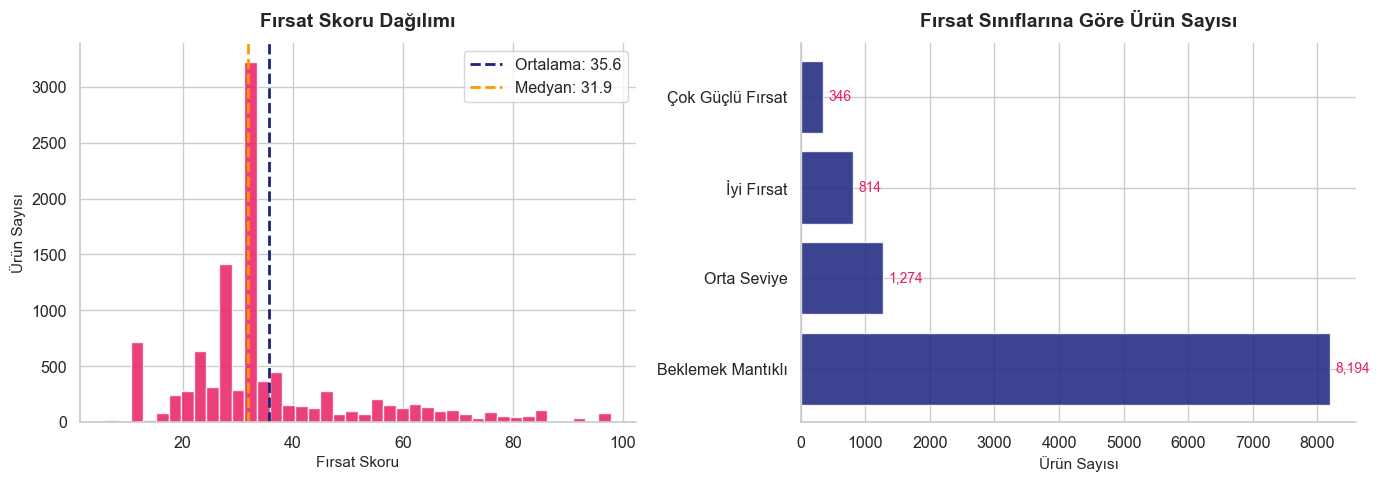

Fırsat skoru özeti:


count    10628.00
mean        35.63
std         16.72
min          6.00
25%         27.64
50%         31.93
75%         37.33
max         97.75
Name: firsat_skoru, dtype: float64

In [20]:
# === FIRSAT SKORU DAĞILIMI ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    firsat_df["firsat_skoru"],
    bins=40,
    color=GRATIS_PEMBE,
    alpha=0.85,
    edgecolor="white"
)

axes[0].set_title("Fırsat Skoru Dağılımı", pad=12)
axes[0].set_xlabel("Fırsat Skoru")
axes[0].set_ylabel("Ürün Sayısı")

axes[0].axvline(firsat_df["firsat_skoru"].mean(), color=GRATIS_LACIVERT, linestyle="--", linewidth=2,
                label=f"Ortalama: {firsat_df['firsat_skoru'].mean():.1f}")
axes[0].axvline(firsat_df["firsat_skoru"].median(), color=ACCENT, linestyle="--", linewidth=2,
                label=f"Medyan: {firsat_df['firsat_skoru'].median():.1f}")
axes[0].legend()

# Sınıf dağılımı
sinif_counts = (
    firsat_df["firsat_sinifi"]
    .value_counts()
    .reindex(["Çok Güçlü Fırsat", "İyi Fırsat", "Orta Seviye", "Beklemek Mantıklı"])
)

bars = axes[1].barh(
    sinif_counts.index[::-1],
    sinif_counts.values[::-1],
    color=GRATIS_LACIVERT,
    alpha=0.85,
    edgecolor="white"
)

axes[1].set_title("Fırsat Sınıflarına Göre Ürün Sayısı", pad=12)
axes[1].set_xlabel("Ürün Sayısı")
axes[1].set_ylabel("")

for bar, val in zip(bars, sinif_counts.values[::-1]):
    axes[1].text(
        val + max(sinif_counts.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=10,
        color=GRATIS_PEMBE
    )

plt.tight_layout()
plt.show()

print("Fırsat skoru özeti:")
display(firsat_df["firsat_skoru"].describe().round(2))

**Bulgu — Fırsat Skoru Dağılımı:**

Fırsat skoru dağılımı, ürünlerin büyük çoğunluğunun düşük ve orta seviyede fırsat sunduğunu göstermektedir.

- **Çok Güçlü Fırsat** sınıfında 346 ürün bulunmaktadır. Bu ürünler, geçmiş fiyat seviyelerine göre oldukça avantajlı konumdadır.
- **İyi Fırsat** sınıfında 814 ürün bulunmaktadır. Bu ürünler tüketici açısından değerlendirilebilir fırsatlar sunmaktadır.
- **Orta Seviye** sınıfında 1274 ürün bulunmaktadır. Bu ürünler takip edilebilir ancak doğrudan güçlü fırsat olarak değerlendirilmemelidir.
- **Beklemek Mantıklı** sınıfında 8194 ürün bulunmaktadır. Bu sonuç, tüm indirimli görünen ürünlerin gerçekten avantajlı olmadığına işaret etmektedir.

**Yorum:** Fırsat skoru, yalnızca ürünün indirimde olup olmadığına bakmadığı için daha seçici bir değerlendirme sunmaktadır. Bu nedenle katalogda çok sayıda ürün indirimli görünse bile, geçmiş fiyat davranışına göre gerçekten avantajlı olan ürün sayısı daha sınırlıdır.

---

## 4) En Yüksek Fırsat Skoruna Sahip Ürünler

Bu bölümde fırsat skoru en yüksek ürünler listelenmiştir. Bu ürünler, güncel fiyatı geçmiş fiyat aralığına göre avantajlı olan, yüksek indirim oranına sahip veya fırsat potansiyeli yüksek kümelerde yer alan ürünlerdir.

In [21]:
# === EN YÜKSEK FIRSAT SKORUNA SAHİP ÜRÜNLER ===

top_firsatlar = (
    firsat_df.sort_values("firsat_skoru", ascending=False)
    .head(20)
)

display(
    top_firsatlar[
        [
            "urun_id",
            "isim",
            "marka",
            "kategori",
            "cluster_adi",
            "guncel_fiyat",
            "min_fiyat",
            "max_fiyat",
            "guncel_indirim",
            "guncel_kampanya",
            "firsat_skoru",
            "firsat_sinifi",
            "url"
        ]
    ]
)

,urun_id,isim,marka,kategori,cluster_adi,guncel_fiyat,min_fiyat,max_fiyat,guncel_indirim,guncel_kampanya,firsat_skoru,firsat_sinifi,url
9837,10800428,Pastel Pure Oje 620,Pastel,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,28.0,28.0,94.5,70.4,250 TL ve Üzeri Alışverişe,97.75,Çok Güçlü Fırsat,https://www.gratis.com/oje/pastel-pure-oje-620...
4033,10207955,Beaulis Fun Jelly Glitz Jel Stick Far 785 Gold...,Beaulis,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,87.0,87.0,349.0,75.1,250 TL ve Üzeri Alışverişe,97.75,Çok Güçlü Fırsat,https://www.gratis.com/far/beaulis-fun-jelly-g...
9963,10878020,Eklips 2’li Kalemtıraş,Eklips,Kişisel Bakım,Sürekli İndirimli Ana Katalog Ürünleri,18.5,18.5,56.0,75.3,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/diger-kisisel-bakim-uru...
10141,10963702,John Frieda Brazilian Sleek Saç Kremi 250 ml,John,Saç Bakım,Sürekli İndirimli Ana Katalog Ürünleri,210.0,210.0,420.5,70.0,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/durulanan-sac-kremleri/...
1382,10131766,Beaulis Kiss It Mat Ruj 194 Heartbreaker,Beaulis,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,49.5,49.5,99.5,75.1,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/ruj/beaulis-kiss-it-mat...
1610,10167399,Maybelline New York Super Stay Matte Ink City ...,Maybelline,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,435.0,435.0,579.0,70.0,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/likit-ruj/maybelline-ne...
1816,10181283,Beaulis Flash It 12'li Far Paleti 208 On The N...,Beaulis,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,110.5,110.5,184.5,70.1,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/far/beaulis-flash-it-12...
1606,10167380,Green Therapy Krem Saç Boyası 4.0 Kahve,Green,Saç Bakım,Sürekli İndirimli Ana Katalog Ürünleri,181.0,181.0,399.0,75.0,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/dogal-sac-boyalari/gree...
1326,10128506,LYKD Honey Prime & Glow Makyaj Bazı 999 Transp...,LYKD,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,129.0,129.0,189.0,75.1,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/makyaj-bazi/lykd-honey-...
2623,10202116,Orien Tıraş Balsamı Hassas Ciltler 200 ml,Orien,Erkek Bakım,Sürekli İndirimli Ana Katalog Ürünleri,47.0,47.0,189.0,75.1,250 TL ve Üzeri Alışverişe,95.50,Çok Güçlü Fırsat,https://www.gratis.com/balsam/orien-tiras-bals...


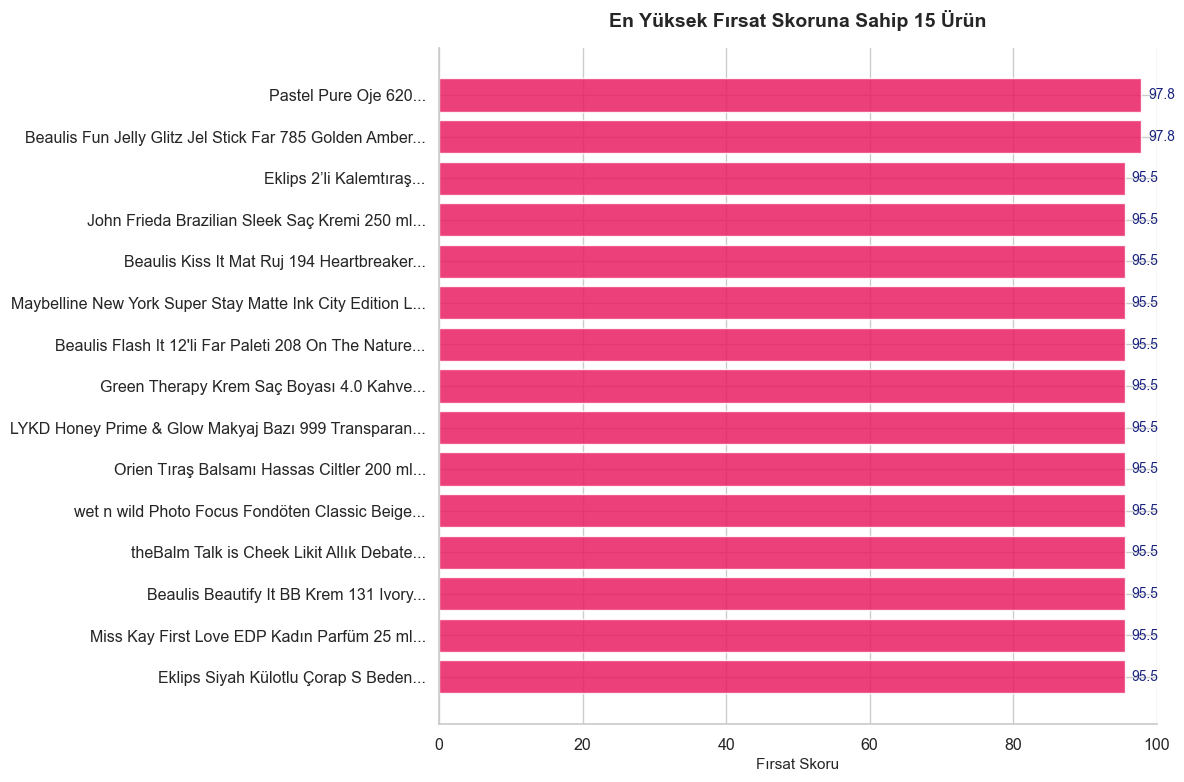

In [22]:
# === TOP 15 FIRSAT ÜRÜNÜ GRAFİĞİ ===

top15 = top_firsatlar.head(15).copy()

# Ürün isimleri çok uzun olduğu için kısaltıyoruz
top15["kisa_isim"] = top15["isim"].str.slice(0, 55) + "..."

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top15["kisa_isim"][::-1],
    top15["firsat_skoru"][::-1],
    color=GRATIS_PEMBE,
    alpha=0.85,
    edgecolor="white"
)

ax.set_title("En Yüksek Fırsat Skoruna Sahip 15 Ürün", pad=15)
ax.set_xlabel("Fırsat Skoru")
ax.set_ylabel("")
ax.set_xlim(0, 100)

for bar, val in zip(bars, top15["firsat_skoru"][::-1]):
    ax.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=10,
        color=GRATIS_LACIVERT
    )

plt.tight_layout()
plt.show()

---

## 5) Kategori Bazında Fırsat Analizi

Fırsat skorları kategori bazında incelenerek hangi kategorilerde daha fazla güçlü fırsat bulunduğu analiz edilmiştir.

In [23]:
# === KATEGORİ BAZINDA FIRSAT ANALİZİ ===

kategori_firsat = firsat_df.groupby("kategori").agg(
    urun_sayisi=("urun_id", "count"),
    ortalama_firsat_skoru=("firsat_skoru", "mean"),
    medyan_firsat_skoru=("firsat_skoru", "median"),
    cok_guclu_firsat_sayisi=("firsat_sinifi", lambda x: (x == "Çok Güçlü Fırsat").sum()),
    iyi_firsat_sayisi=("firsat_sinifi", lambda x: (x == "İyi Fırsat").sum())
).round(2)

kategori_firsat["cok_guclu_firsat_orani"] = (
    kategori_firsat["cok_guclu_firsat_sayisi"] / kategori_firsat["urun_sayisi"] * 100
).round(2)

kategori_firsat = kategori_firsat.sort_values("ortalama_firsat_skoru", ascending=False)

display(kategori_firsat)

,urun_sayisi,ortalama_firsat_skoru,medyan_firsat_skoru,cok_guclu_firsat_sayisi,iyi_firsat_sayisi,cok_guclu_firsat_orani
kategori,,,,,,
Elektrikli Ürünler,53,45.18,36.21,3,1,5.66
Ev & Yaşam,92,42.09,39.19,14,3,15.22
Moda & Aksesuar,357,42.03,35.19,42,52,11.76
Güneş Ürünleri,203,39.74,31.93,1,34,0.49
Makyaj,3666,37.96,31.97,123,358,3.36
Saç Bakım,1381,36.92,31.93,57,145,4.13
Cilt Bakım,1617,36.40,31.93,46,118,2.84
Parfüm & Deodorant,553,34.61,31.80,26,32,4.70
Anne & Bebek,196,33.90,30.17,1,16,0.51


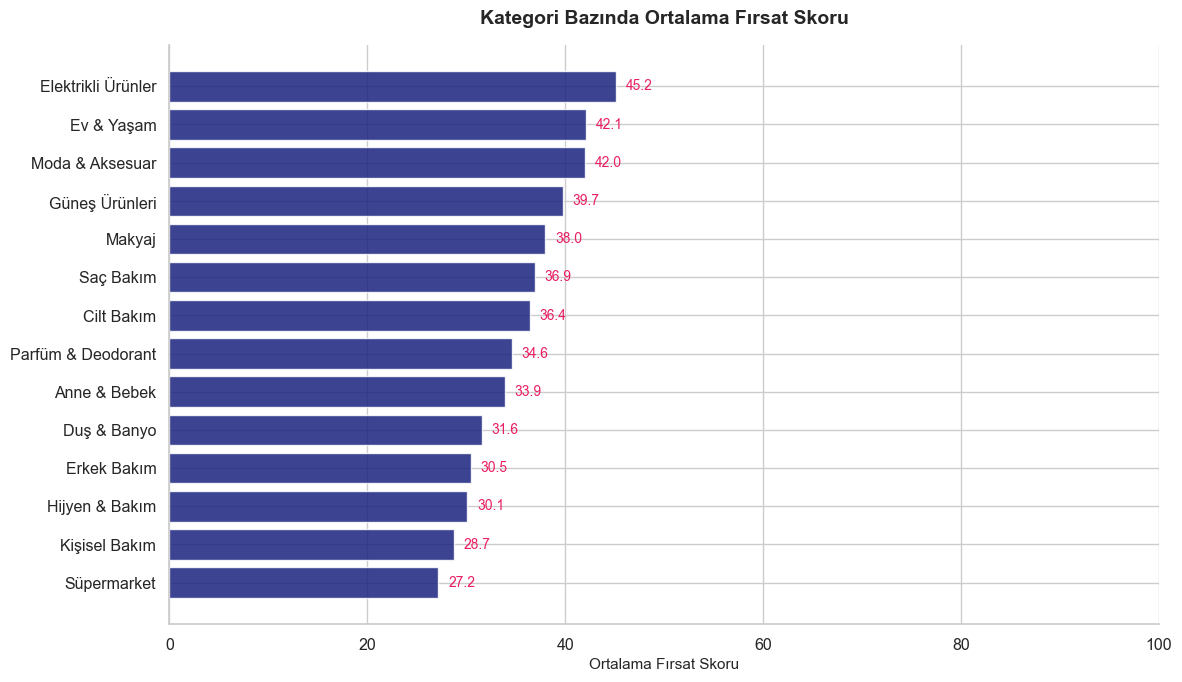

In [24]:
# === KATEGORİ BAZINDA ORTALAMA FIRSAT SKORU GRAFİĞİ ===

kategori_plot = kategori_firsat.sort_values("ortalama_firsat_skoru", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    kategori_plot.index,
    kategori_plot["ortalama_firsat_skoru"],
    color=GRATIS_LACIVERT,
    alpha=0.85,
    edgecolor="white"
)

ax.set_title("Kategori Bazında Ortalama Fırsat Skoru", pad=15)
ax.set_xlabel("Ortalama Fırsat Skoru")
ax.set_ylabel("")
ax.set_xlim(0, 100)

for bar, val in zip(bars, kategori_plot["ortalama_firsat_skoru"]):
    ax.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=10,
        color=GRATIS_PEMBE
    )

plt.tight_layout()
plt.show()

---

## 6) Küme Bazında Fırsat Analizi

Fırsat skorları, önceki notebook'ta oluşturulan ürün davranış kümelerine göre incelenmiştir. Böylece hangi ürün davranış profilinin daha yüksek fırsat potansiyeli taşıdığı analiz edilmiştir.

In [25]:
# === KÜME BAZINDA FIRSAT ANALİZİ ===

kume_firsat = firsat_df.groupby("cluster_adi").agg(
    urun_sayisi=("urun_id", "count"),
    ortalama_firsat_skoru=("firsat_skoru", "mean"),
    medyan_firsat_skoru=("firsat_skoru", "median"),
    cok_guclu_firsat_sayisi=("firsat_sinifi", lambda x: (x == "Çok Güçlü Fırsat").sum()),
    iyi_firsat_sayisi=("firsat_sinifi", lambda x: (x == "İyi Fırsat").sum())
).round(2)

kume_firsat["cok_guclu_firsat_orani"] = (
    kume_firsat["cok_guclu_firsat_sayisi"] / kume_firsat["urun_sayisi"] * 100
).round(2)

display(kume_firsat.sort_values("ortalama_firsat_skoru", ascending=False))

,urun_sayisi,ortalama_firsat_skoru,medyan_firsat_skoru,cok_guclu_firsat_sayisi,iyi_firsat_sayisi,cok_guclu_firsat_orani
cluster_adi,,,,,,
Stabil ve Düşük Kampanyalı Ürünler,655,40.27,41.31,4,56,0.61
Sürekli İndirimli Ana Katalog Ürünleri,9020,36.62,31.93,320,655,3.55
Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,953,23.08,12.75,22,103,2.31


**Bulgu — Küme Bazında Fırsat Potansiyeli:**

Fırsat skorları, ürünlerin ait olduğu davranış kümelerine göre farklılaşmaktadır.

- **Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri**, yüksek fırsat potansiyeli taşıyan ürünleri barındırır. Bu ürünler her zaman indirimli olmasa da, doğru zamanda yüksek avantaj sağlayabilir.
- **Sürekli İndirimli Ana Katalog Ürünleri** genellikle indirimli görünse de, fırsat skoru ürünün geçmiş fiyatına göre gerçekten avantajlı olup olmadığını ayırmaya yardımcı olur.
- **Stabil ve Düşük Kampanyalı Ürünler** daha sınırlı fırsat potansiyeline sahiptir; bu ürünlerde fiyat hareketi daha düşük olduğu için bekleyerek çok yüksek avantaj elde etme olasılığı sınırlı olabilir.

Bu bulgu, kümeleme aşamasında elde edilen davranış profillerinin fırsat skorunu yorumlamada anlamlı olduğunu göstermektedir.

---

## 7) Tüketici Karar Önerisi

Fırsat skoruna göre tüketiciye öneri üretmek için basit bir karar mantığı oluşturulmuştur.

Bu karar mantığı modelin nihai kullanıcı tarafındaki yorumunu temsil eder.

In [26]:
# === TÜKETİCİ KARAR ÖNERİSİ ===

def karar_onerisi(row):
    if row["firsat_skoru"] >= 80:
        return "Almak için güçlü aday"
    elif row["firsat_skoru"] >= 60:
        return "Değerlendirilebilir"
    elif row["firsat_skoru"] >= 40:
        return "Takip edilebilir"
    else:
        return "Beklemek daha mantıklı"

firsat_df["karar_onerisi"] = firsat_df.apply(karar_onerisi, axis=1)

karar_ozet = firsat_df["karar_onerisi"].value_counts()

display(karar_ozet)

karar_onerisi
Beklemek daha mantıklı    8194
Takip edilebilir          1274
Değerlendirilebilir        814
Almak için güçlü aday      346
Name: count, dtype: int64

---

## 8) Örnek Ürün Kartları

Aşağıda farklı fırsat sınıflarından seçilmiş ürünler için tüketiciye yönelik özet kartlar gösterilmiştir.

In [27]:
# === ÖRNEK ÜRÜN KARTLARI ===

ornek_kartlar = (
    firsat_df.sort_values("firsat_skoru", ascending=False)
    .groupby("firsat_sinifi")
    .head(3)
)

display(
    ornek_kartlar[
        [
            "isim",
            "marka",
            "kategori",
            "cluster_adi",
            "guncel_fiyat",
            "min_fiyat",
            "max_fiyat",
            "guncel_indirim",
            "firsat_skoru",
            "firsat_sinifi",
            "karar_onerisi"
        ]
    ].sort_values("firsat_skoru", ascending=False)
)

,isim,marka,kategori,cluster_adi,guncel_fiyat,min_fiyat,max_fiyat,guncel_indirim,firsat_skoru,firsat_sinifi,karar_onerisi
9837,Pastel Pure Oje 620,Pastel,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,28.0,28.0,94.5,70.4,97.75,Çok Güçlü Fırsat,Almak için güçlü aday
4033,Beaulis Fun Jelly Glitz Jel Stick Far 785 Gold...,Beaulis,Makyaj,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,87.0,87.0,349.0,75.1,97.75,Çok Güçlü Fırsat,Almak için güçlü aday
9963,Eklips 2’li Kalemtıraş,Eklips,Kişisel Bakım,Sürekli İndirimli Ana Katalog Ürünleri,18.5,18.5,56.0,75.3,95.50,Çok Güçlü Fırsat,Almak için güçlü aday
10371,Taft Power Kaşmir Saç Spreyi 250 ml,Taft,Saç Bakım,Sürekli İndirimli Ana Katalog Ürünleri,169.0,167.0,249.0,59.6,79.95,İyi Fırsat,Değerlendirilebilir
2288,Mov Glitter Yonca Far Paleti No: 3,Mov,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,66.0,49.5,115.0,60.0,79.88,İyi Fırsat,Değerlendirilebilir
9128,Urban Care Summer Glow Aşamalı Renk Açıcı Spre...,Urban,Saç Bakım,Stabil ve Düşük Kampanyalı Ürünler,199.0,199.0,299.0,66.8,79.63,İyi Fırsat,Değerlendirilebilir
9883,Pastel Profashion Duo Blush Set Cheek to Cheek...,Pastel,Makyaj,Sürekli İndirimli Ana Katalog Ürünleri,344.0,219.5,549.0,50.1,59.97,Orta Seviye,Takip edilebilir
10074,Arifoğlu Kaş Kirpik Bakım Yağı 10 ml + 10 ml,Arifoğlu,Cilt Bakım,Oynak Fiyatlı ve Dönemsel Fırsat Ürünleri,196.5,131.0,328.0,40.1,59.97,Orta Seviye,Takip edilebilir
7737,Dove Men +Care Clean Comfort Erkek Roll On Deo...,Dove,Erkek Bakım,Sürekli İndirimli Ana Katalog Ürünleri,219.0,156.0,354.0,43.8,59.95,Orta Seviye,Takip edilebilir
8421,Celenes Thermal Nemlendirici ve Canlandırıcı Y...,Celenes,Cilt Bakım,Sürekli İndirimli Ana Katalog Ürünleri,218.0,209.5,218.0,68.8,39.99,Beklemek Mantıklı,Beklemek daha mantıklı


---

## 9) Fırsat Skorlarının Kaydedilmesi

Fırsat skoru, fırsat sınıfı ve tüketici karar önerisi ürün bazlı tabloya eklenmiş ve sonraki raporlama aşamasında kullanılmak üzere kaydedilmiştir.

In [28]:
# === FIRSAT SKORLARINI KAYDET ===

OUTPUT_PATH = PROCESSED_DIR / "urun_firsat_skorlari.csv"

firsat_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("Fırsat skorları başarıyla kaydedildi ✓")
print(f"Dosya yolu: {OUTPUT_PATH}")

# Doğrulama
firsat_check = pd.read_csv(OUTPUT_PATH, encoding="utf-8-sig")

print("\n=== KAYIT DOĞRULAMA ===")
print(f"Okunan satır sayısı: {len(firsat_check):,}")
print(f"Orijinal satır sayısı: {len(firsat_df):,}")
print(f"Sütunlar eşleşiyor mu?: {list(firsat_check.columns) == list(firsat_df.columns)}")

Fırsat skorları başarıyla kaydedildi ✓
Dosya yolu: ..\data\processed\urun_firsat_skorlari.csv

=== KAYIT DOĞRULAMA ===
Okunan satır sayısı: 10,628
Orijinal satır sayısı: 10,628
Sütunlar eşleşiyor mu?: True


---

## Notebook Özeti

Bu notebook kapsamında ürünlere tüketici perspektifinden yorumlanabilir bir **fırsat skoru** atanmıştır.

### Yapılan İşlemler

1. Temiz ürün-gün verisi ve kümeleme sonuçları okundu.
2. Her ürün için en güncel fiyat, indirim ve kampanya bilgisi çıkarıldı.
3. Ürün özellikleri ile güncel ürün durumu birleştirildi.
4. Fırsat skoru dört bileşen üzerinden hesaplandı:
   - Geçmiş fiyata göre avantaj
   - Güncel indirim derinliği
   - Kampanya etkisi
   - Küme davranışı etkisi
5. Ürünler fırsat skoruna göre dört sınıfa ayrıldı:
   - Çok Güçlü Fırsat
   - İyi Fırsat
   - Orta Seviye
   - Beklemek Mantıklı
6. Kategori ve küme bazında fırsat analizleri yapıldı.
7. Tüketiciye yönelik karar önerisi üretildi.
8. Sonuçlar `urun_firsat_skorlari.csv` dosyasına kaydedildi.

### Temel Sonuç

Veri setinde çok sayıda ürün indirimli görünmesine rağmen, fırsat skoru daha seçici bir değerlendirme sunmuştur. Bu nedenle her indirimli ürünün tüketici açısından eşit derecede avantajlı olmadığı görülmüştür.

### Proje Açısından Katkı

Bu aşama, projenin tüketici tarafındaki ana çıktısını üretmektedir:

> Ürün indirimde mi sorusundan daha güçlü olarak, ürün şu anda gerçekten avantajlı mı sorusuna veri temelli cevap verir.